# Setup

In [1]:
import sys, os
from dotenv import load_dotenv

IN_COLAB = ('google.colab' in sys.modules)

if IN_COLAB:
    from google.colab import drive, userdata
    drive.mount('/content/drive')

    BASE_PATH = '/content/drive/MyDrive/python/text-autocomplete-rnn'

    sys.path.insert(0, BASE_PATH)

    os.environ['CLEARML_KEY'] = userdata.get('CLEARML_KEY')
    os.environ['CLEARML_SECRET'] = userdata.get('CLEARML_SECRET')
else:
    BASE_PATH = os.getcwd()
    load_dotenv()

In [18]:
import datetime
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import yaml
from collections import Counter
from torch.optim import Adam
from torch.utils.data import random_split
from transformers import BertTokenizerFast, pipeline
from tqdm.auto import tqdm

from src import (data_utils, model_scoring, monitoring,
                 seq2seq_model, train_utils)
from src.next_token_dataset import NextTokenDataset, next_token_data_loader

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

torch.manual_seed(42) 

config_file_path = os.path.join(BASE_PATH, 'configs/config.yaml')

with open(config_file_path, 'r') as file:
    config = yaml.safe_load(file)

ORIGINAL_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], config['dataset']['original_filename'])

basename = os.path.basename(config['dataset']['original_filename'])
DATASET_BASENAME = os.path.splitext(basename)[0]

PREPROCESSED_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_preprocessed.csv')
TRAIN_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_train.csv')
VAL_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_val.csv')
TEST_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_test.csv')

MODEL_DIR = os.path.join(BASE_PATH, config['model']['dir'])

MAX_SEQ_LENGTH = 5

monitoring.init_clearml(config['clearml'])



Using cuda device
ClearML enabled


# Data preprocessing

In [4]:
if not os.path.exists(ORIGINAL_DATASET_PATH):
    urllib.request.urlretrieve(config['dataset']['source'], ORIGINAL_DATASET_PATH)

In [5]:
if not os.path.exists(PREPROCESSED_DATASET_PATH):
    dataset = data_utils.load_data(ORIGINAL_DATASET_PATH)

    preprocessed = [data_utils.clear_text(line) for line in dataset]
    preprocessed = [line for line in preprocessed if line != '']

    data_utils.store_data(preprocessed, PREPROCESSED_DATASET_PATH)

    dataset = preprocessed
else:
    dataset = np.array(data_utils.load_data(PREPROCESSED_DATASET_PATH))

In [6]:
if (not os.path.exists(TRAIN_DATASET_PATH) or 
    not os.path.exists(VAL_DATASET_PATH) or 
    not os.path.exists(VAL_DATASET_PATH)):

    val_size = int(len(dataset) * 0.1)
    test_size = val_size
    train_size = len(dataset) - val_size - test_size

    torch.manual_seed(42)
    train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

    data_utils.store_data(train_data, TRAIN_DATASET_PATH)
    data_utils.store_data(val_data, VAL_DATASET_PATH)
    data_utils.store_data(test_data, TEST_DATASET_PATH)
else:
    train_data = data_utils.load_data(TRAIN_DATASET_PATH)
    val_data = data_utils.load_data(VAL_DATASET_PATH)
    test_data = data_utils.load_data(TEST_DATASET_PATH)

max_examples = config['dataset']['max_examples']
if max_examples > 0:
    train_data = train_data.dataset[:max_examples] if isinstance(train_data, torch.utils.data.dataset.Subset) else train_data[:max_examples]
    val_data = val_data.dataset[:max_examples] if isinstance(val_data, torch.utils.data.dataset.Subset) else val_data[:max_examples]
    test_data = test_data.dataset[:max_examples] if isinstance(test_data, torch.utils.data.dataset.Subset) else test_data[:max_examples]

print(f'Train size: {len(train_data)}')
print(f'Val size: {len(val_data)}')
print(f'Test size: {len(test_data)}')

Train size: 1277552
Val size: 159693
Test size: 159693


# Data Exploration

Всего примеров: 1596938
Статистика по количеству строк:
Среднее: 12.78
Медиана: 12.00
5%: 3.00
95%: 25.00


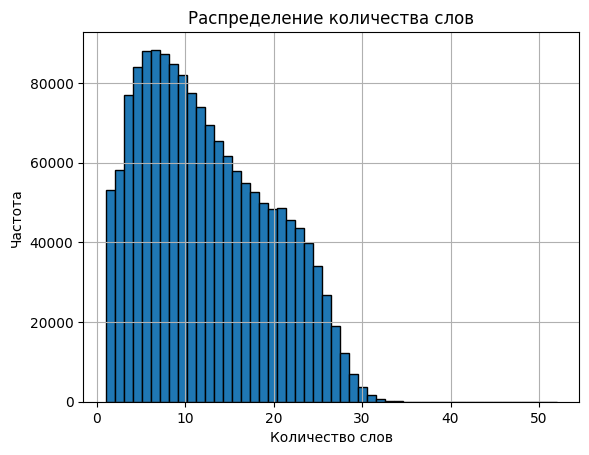

In [7]:
words_count = np.array([len(line.split()) for line in dataset])

print(f'Всего примеров: {len(dataset)}')
print('Статистика по количеству строк:')
print(f'Среднее: {np.mean(words_count):.2f}')
print(f'Медиана: {np.median(words_count):.2f}')
print(f'5%: {np.percentile(words_count, 5):.2f}')
print(f'95%: {np.percentile(words_count, 95):.2f}')

plt.hist(words_count, bins=50, edgecolor='black')
plt.title("Распределение количества слов")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

Большинство данных имеет от 3 до 26 слов, что позволит использовать несложные RNN

# Data Preparation

In [8]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# чтобы не добавлять новых токенов, будем считать CLS за начало фразы, SEP за конец
special_tokens = tokenizer.special_tokens_map
BOS_TOKEN_ID = tokenizer.convert_tokens_to_ids(special_tokens['cls_token'])
EOS_TOKEN_ID = tokenizer.convert_tokens_to_ids(special_tokens['sep_token'])
PAD_TOKEN_ID = tokenizer.convert_tokens_to_ids(special_tokens['pad_token'])


In [9]:
print('Creating train dataset')
train_dataset = NextTokenDataset(
    train_data,
    tokenizer,
    max_output_length=MAX_SEQ_LENGTH,
    split_num=config['dataset']['train_set_split_num']
)

# для валидации и теста три четверти текста - промпт, четверть - таргет
print('Creating val dataset')
val_dataset = NextTokenDataset(
    val_data,
    tokenizer,
    max_output_length=MAX_SEQ_LENGTH,
    split_num=1
)
print('Creating test dataset')
test_dataset = NextTokenDataset(
    test_data,
    tokenizer,
    max_output_length=MAX_SEQ_LENGTH,
    split_num=1
)

batch_size = config['train']['batch_size']

train_loader = next_token_data_loader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = next_token_data_loader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = next_token_data_loader(test_dataset, batch_size=batch_size, shuffle=False)

Creating train dataset


100%|██████████| 1277552/1277552 [02:00<00:00, 10609.74it/s]


Creating val dataset


100%|██████████| 159693/159693 [00:15<00:00, 10209.19it/s]


Creating test dataset


100%|██████████| 159693/159693 [00:14<00:00, 10781.74it/s]


# Training

In [38]:
def save_model(model, run_id, epoch):
    filename = f'{run_id}-{device}-{epoch}.pth'
    torch.save(model.state_dict(), os.path.join(MODEL_DIR, filename))

def print_random_predictions(model, data_loader, num):
    model.eval()

    batch = next(iter(data_loader))

    random_ints = torch.randint(low=0, high=batch['heads'].size(0), size=(num,))
    index = random_ints.tolist()

    input_ids = batch['heads'][index, :]
    target_ids = batch['tails'][index, :]

    prediction_ids = model.generate(input_ids.to(device), max_new_tokens=MAX_SEQ_LENGTH)

    inputs = tokenizer.batch_decode(input_ids, skip_special_tokens=True)
    targets = tokenizer.batch_decode(target_ids, skip_special_tokens=True)
    predictions = tokenizer.batch_decode(prediction_ids, skip_special_tokens=True)

    for inp, tgt, pred in zip(inputs, targets, predictions):
        print(f'Prompt: {inp}')
        print(f'Target: {tgt}')
        print(f'Prediction: {pred}\n')

Для часто встречающихся токенов снизим вес для loss функции, иначе модель упирается и предсказывает только их

In [11]:

token_cnt = Counter()
for line in train_data:
    token_ids  = tokenizer.encode(line, add_special_tokens=False)
    token_cnt.update(token_ids)

frequent_tokens = [id for id, _ in token_cnt.most_common(25)]

weights = torch.ones((tokenizer.vocab_size, ))

for id in frequent_tokens:
    weights[id] = 0.1

weights[PAD_TOKEN_ID] = 1e-10
weights[BOS_TOKEN_ID] = 1e-10
weights[EOS_TOKEN_ID] = 1e-10

print('Frequent tokens:')
print(tokenizer.decode(frequent_tokens))

token_cnt.total()

Frequent tokens:
i ' to the a my it you and is t in for s oft that on me so have ms but just


19335289

In [12]:

model = seq2seq_model.NextTokenGenerator(
    tokenizer.vocab_size,
    hidden_dim=config['model']['hidden_dim']
)
model.to(device)

weights = weights.to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN_ID, weight=weights)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
trainer = train_utils.Seq2SeqTrainer()

In [13]:
now = datetime.datetime.now()
run_id = f'seq2seq_weights-{now.strftime("%Y%m%d_%H%M%S")}'

task_config = {
    'run_id': run_id,
    'device': device,
    'dataset_size': len(train_dataset),
    'batch_size': config['train']['batch_size'],
    'epochs': config['train']['max_epoch'],
    'hidden size': config['model']['hidden_dim'],
}



In [25]:
import importlib

importlib.reload(model_scoring)

<module 'src.model_scoring' from '/home/ubuntu/text-autocomplete-rnn/src/model_scoring.py'>

In [ ]:
all_train = []
all_val = []

with monitoring.ClearMLTask(project_name='RNN Autocomplete', task_name='Seq2seq2 model', task_config=task_config) as task:
    for epoch in range(config['train']['max_epoch']):
        train_loss, val_loss = train_utils.train_val_cycle(
            train_data=train_loader,
            val_data=val_loader,
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            trainer=trainer,
            device=device
        )

        rouge1 = 0
        rouge1, _ = model_scoring.score_model(model, val_loader, tokenizer, max_new_tokens=MAX_SEQ_LENGTH, device=device)

        task.report_scalar('Loss', 'train', train_loss, epoch)
        task.report_scalar('Loss', 'validate', val_loss, epoch)
        
        task.report_scalar('Rouge', 'validate', val_loss, epoch)

        all_train.append(train_loss)
        all_val.append(val_loss)
        
        print(f'Epoch {epoch + 1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, rouge score: {rouge1}')

        model.eval()
        print('Prediction example:')
        print_random_predictions(model, val_loader, 1)

        # Сохраним промежуточные веса
        save_model(model, run_id, epoch + 1)

plt.plot(all_train, label='train')
plt.plot(all_val, label='val')


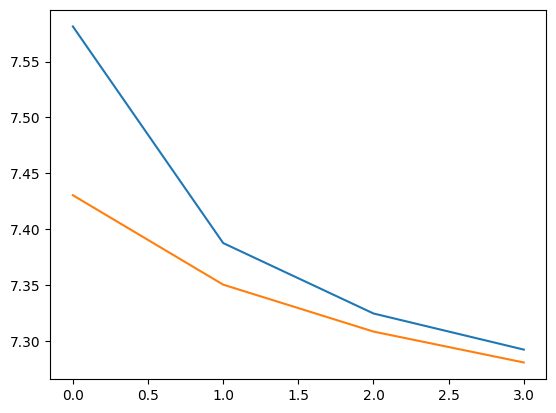

In [19]:
plt.plot(all_train, label='train')
plt.plot(all_val, label='val')
plt.xlabel = 'Epoch'
plt.ylabel = 'Loss'
plt.show()

# Примеры сгенерированных текстов

In [30]:
generator = pipeline(
    'text-generation',
    model='distilgpt2',
    device=(0 if torch.cuda.is_available() else -1)
)
generator.tokenizer.pad_token_id = PAD_TOKEN_ID
generator.tokenizer.padding_side = 'left'

batch = next(iter(test_loader))

random_ints = torch.randint(low=0, high=batch['heads'].size(0), size=(3,))
index = random_ints.tolist()

input_ids = batch['heads'][index, :]
target_ids = batch['tails'][index, :]

prompts = tokenizer.batch_decode(input_ids, skip_special_tokens=True)
targets = tokenizer.batch_decode(target_ids, skip_special_tokens=True)

seq2seq_predictions = model.generate(input_ids.to(device), max_new_tokens=MAX_SEQ_LENGTH)
seq2seq_predictions = tokenizer.batch_decode(seq2seq_predictions, skip_special_tokens=True)

generator_predictions = generator(prompts, max_new_tokens=MAX_SEQ_LENGTH, pad_token_id=PAD_TOKEN_ID, )
generator_predictions = [line[0]['generated_text'].strip() for line in generator_predictions]

for i in range(3):
    print(f'Example {i + 1}:')
    print(f'Prompt: {prompts[i]}')
    print(f'Target: {targets[i]}')
    print(f'Predicted by model: {seq2seq_predictions[i]}')
    print(f'Predicted by transformer: {generator_predictions[i]}\n')


Device set to use cuda:0


Example 1:
Prompt: beach in the rain sounds good
Target: to me
Predicted by model: day day today today day
Predicted by transformer: beach in the rain sounds good, but not for a

Example 2:
Prompt: i ' m walking the red carpet mary ' s movie premiere repping
Target: for no h8
Predicted by model: with with with good now
Predicted by transformer: i ' m walking the red carpet mary ' s movie premiere repping in theaters

Example 3:
Prompt: hmm shoe horn sonata speech due tomoz for me ill so walk off while doing
Target: it then cry as usual
Predicted by model: up with with with day
Predicted by transformer: hmm shoe horn sonata speech due tomoz for me ill so walk off while doing the first thing i am



# Финальная оценка всех моделей

Используется test датасет

In [34]:
final_metrics = {
    'seq2seq': model_scoring.score_model(model, test_loader, tokenizer, max_new_tokens=MAX_SEQ_LENGTH, device=device),
    'transformer': model_scoring.score_transformer(generator, test_loader, tokenizer, max_length=MAX_SEQ_LENGTH)
}

print(f'{"Model":<12} | {"ROUGE1":<6} | {"ROUGE2":<6}')
print('-' * 35)
for model_name, (rouge1, rouge2) in final_metrics.items():
    print(f'{model_name:<12} | {rouge1:.4f} | {rouge2:.4f}')

100%|██████████| 621/621 [05:21<00:00,  1.93it/s]


Model        | ROUGE1 | ROUGE2
-----------------------------------
seq2seq      | 0.0310 | 0.0018
transformer  | 0.0402 | 0.0032


# Заключение

Входящий корпус текста специфичен, имеет ярко выраженный стиль, обильно использует слова, встречающиеся только в формате чатов/твитов.

Ни разработанная модель, ни трансформер в общем случае не улавливают основную мысль текста, смысл сгененированных дополнений не продолжает мысль исходной фразы. Точного попадания также не дает ни та, ни другая модель.

Метрики у обеих моделей одинаково плохие.

Трансформер более "умный", чем предоставленный корпус текста. Он генерирует более содержательные и более грамотные фразы.

Разработанная модель, хотя имеет неважные показатели loss на валидации, дает осмысленные предсказания (насколько позволяет корпус текстов).

Так как важны скорость инференса и экономия ресурсов, рекомендую использовать более легкую самописную модель.

In [39]:
print('Примеры предсказаний:')
print_random_predictions(model, test_loader, 10)

Примеры предсказаний:
Prompt: not feelin 2d
Target: ##ay
Prediction: day daylll

Prompt: i just wish matt were here
Target: with me
Prediction: upllll

Prompt: exam not too bad today just have to revise the hell out of physics
Target: for friday aka my birthday
Prediction: with with this day day

Prompt: i know i don ' t know if i can watch it will be such
Target: a sad night for everyone
Prediction: good with loll

Prompt: we don ' t need automatic followers prefer slower growth
Target: with real participation
Prediction: with yourlll

Prompt: finally cutting my quilt
Target: strips
Prediction: hurts now nowll

Prompt: thank you very much for hte followfrid
Target: ##ay take care
Prediction: ##ayay are are x

Prompt: and now the leg is shaved getting dressed now is it weird that i picked
Target: out 3 options for today
Prediction: like not with this lo

Prompt: watching csi
Target: ny
Prediction: today today today fun fun

Prompt: i actually heart the clouds i lived in monterey for fi